# 06 — Cancellation Analysis
**Phase 6 — Brazilian E-Commerce Analytics (Olist)**

Business questions answered:
- What is the overall distribution of order statuses?
- How have cancellations trended month over month?
- Which product categories have the highest number of cancellations?
- Which categories have the highest cancellation rate (relative to total orders)?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
query = """
    SELECT 
        order_status,
        COUNT(*) AS total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM orders_clean
    GROUP BY order_status
    ORDER BY total DESC
"""

status = pd.read_sql(query, engine)
status

,order_status,total,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


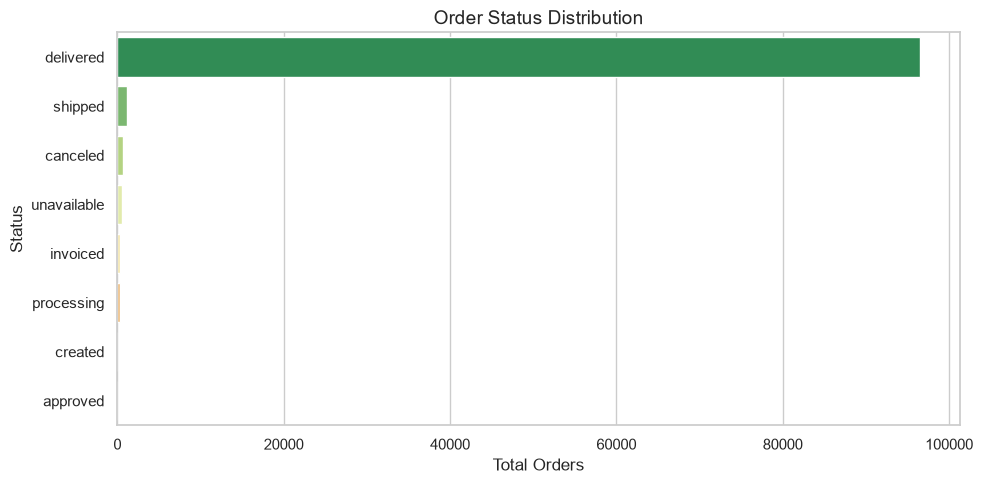

In [3]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=status, x="total", y="order_status",
    hue="order_status", palette="RdYlGn_r", legend=False
)
plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Total Orders")
plt.ylabel("Status")
plt.tight_layout()
plt.show()

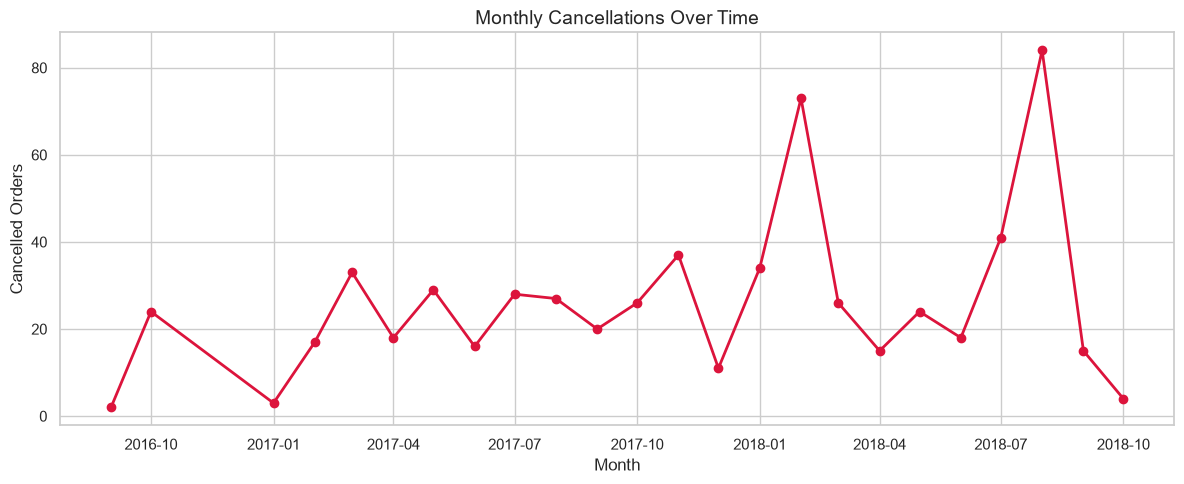

In [4]:
query = """
    SELECT
        DATE_TRUNC('month', order_purchase_timestamp) AS month,
        COUNT(*) AS cancelled_orders
    FROM orders_clean
    WHERE order_status = 'canceled'
    GROUP BY month
    ORDER BY month
"""

monthly_cancel = pd.read_sql(query, engine)
monthly_cancel["month"] = pd.to_datetime(monthly_cancel["month"])

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_cancel["month"],
    monthly_cancel["cancelled_orders"],
    marker="o", color="crimson", linewidth=2
)
plt.title("Monthly Cancellations Over Time", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Cancelled Orders")
plt.tight_layout()
plt.show()

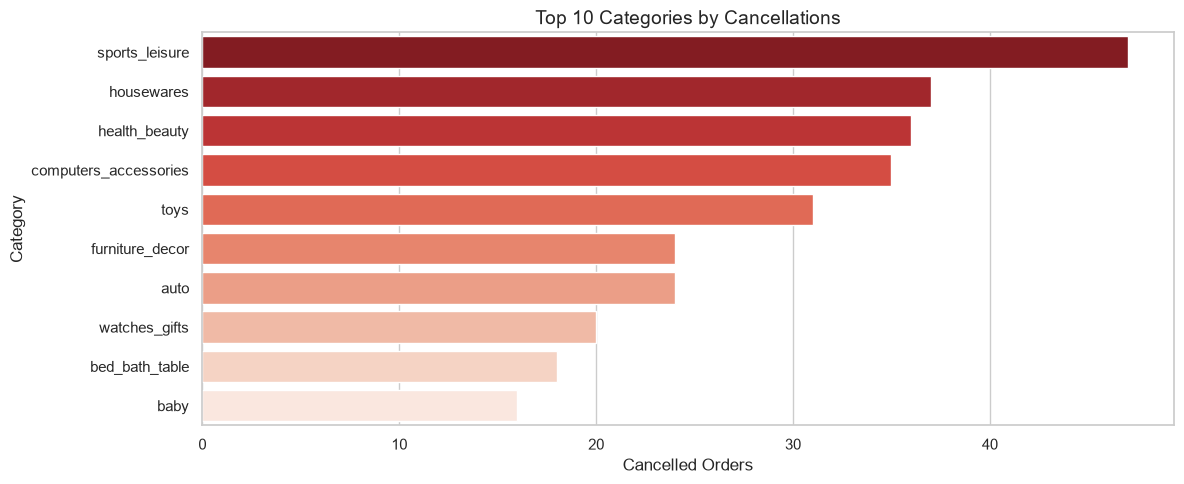

In [5]:
query = """
    SELECT
        p.product_category_name_english AS category,
        COUNT(DISTINCT o.order_id)      AS cancelled_orders
    FROM orders_clean o
    JOIN order_items oi    ON o.order_id = oi.order_id
    JOIN products_clean p  ON oi.product_id = p.product_id
    WHERE o.order_status = 'canceled'
      AND p.product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY cancelled_orders DESC
    LIMIT 10
"""

cancel_category = pd.read_sql(query, engine)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=cancel_category, x="cancelled_orders", y="category",
    hue="category", palette="Reds_r", legend=False
)
plt.title("Top 10 Categories by Cancellations", fontsize=14)
plt.xlabel("Cancelled Orders")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

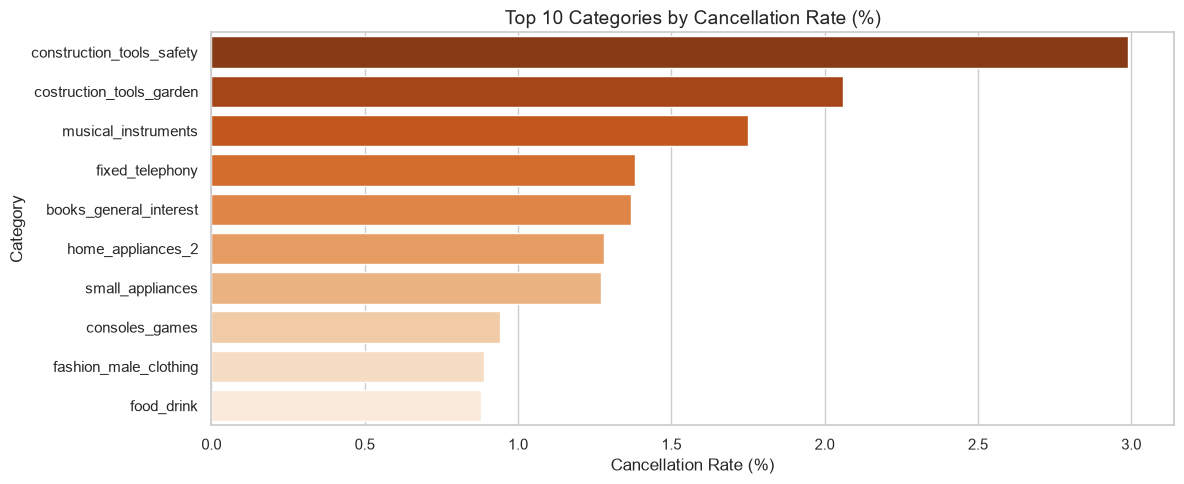

In [6]:
query = """
    SELECT
        p.product_category_name_english AS category,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(CASE WHEN o.order_status = 'canceled' THEN 1 ELSE 0 END) AS cancelled,
        ROUND(
            SUM(CASE WHEN o.order_status = 'canceled' THEN 1 ELSE 0 END) 
            * 100.0 / COUNT(DISTINCT o.order_id), 2
        ) AS cancel_rate
    FROM orders_clean o
    JOIN order_items oi   ON o.order_id = oi.order_id
    JOIN products_clean p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY category
    HAVING COUNT(DISTINCT o.order_id) > 100
    ORDER BY cancel_rate DESC
    LIMIT 10
"""

cancel_rate = pd.read_sql(query, engine)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=cancel_rate, x="cancel_rate", y="category",
    hue="category", palette="Oranges_r", legend=False
)
plt.title("Top 10 Categories by Cancellation Rate (%)", fontsize=14)
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()